# Liver — Xenium transcriptomics + DESI metabolomics

- This tutorial runs LYNX on a human liver sample that pairs **Xenium** (the *reference* spatial transcriptomics modality) with **DESI** (the
*query* spatial metabolomics modality). 
- LYNX learns a shared latent embedding and predicts the
"portal-vein" - "central vein" zonation gradient as a principal **curve**, discretizes
it into zones, and infers cell–cell interactions along the gradient.


In [1]:
import os
import numpy as np
import scanpy as sc
import squidpy as sq
import torch
import torch.nn as nn

from matplotlib import rcParams
rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})
import lynx

/home/yinuo/Desktop/azizi_lab/IMS/env/lib/python3.9/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


## 1. Load and pair the two modalities

In [2]:
# Hyperparameters
n_subgraphs = 16
n_hidden = 32
n_latent = 6
n_epochs = 500
lr = 1e-2
patience = 20

xenium_path = "../../data/xenium/"
desi_path = "../../data/desi/"
sample_id = "NIH_F5_proseg"

adata_xenium = lynx.io.load_xenium(os.path.join(xenium_path, sample_id), load_img=False)
adata_desi = sc.read_h5ad(os.path.join(desi_path, sample_id + ".h5"))

# Keep only cells/pixels with a valid cross-modal mapping.
adata_xenium, adata_desi = lynx.io.filter_cells(adata_xenium, adata_desi, by="map")

cluster_key = "subtype"
cluster_labels = adata_xenium.obs[cluster_key].cat.categories  # individual cell types

In [3]:
cluster_labels

Index(['Cholangiocytes', 'Perisinusoidal stroma', 'Hepatocytes', 'Kupffer',
       'LSECs', 'Monocyte-derived macrophages', 'Plasma/B-cells',
       'Portal Fibroblasts', 'SMCs', 'T-cells', 'Vascular Endothelial'],
      dtype='object')

## 2. Build the spatial hetero-graph, configure the model

In [4]:
graph_data = lynx.dataset.HeteroDataset(
    adatas_ref=adata_xenium,
    adatas_query=adata_desi,
    n_subgraphs=n_subgraphs,
    is_weighted=True,
    alpha=0.5,
    cluster_key=cluster_key,
)

train_configs = lynx.config.set_train_configs(
    n_epochs=n_epochs, lr=lr, patience=patience,
    device=torch.device("cuda"),
)

model_configs = lynx.config.set_model_configs(
    graph_data=graph_data,
    c_hidden=n_hidden,
    c_latent=n_latent,
    act=nn.SiLU(),
    infer_cell_interaction=True,   # enable cell-cell interaction inference
)

## 3. Train the model

Epoch 172 train -ELBO: 161.515; val -ELBO: 158.706; val R2: 0.912; q(z) corr: 0.426; p(z) corr: 0.655:  35%|███▍      | 173/500 [02:45<05:12,  1.05it/s]


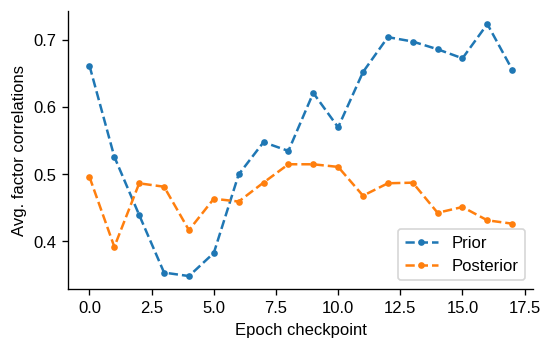

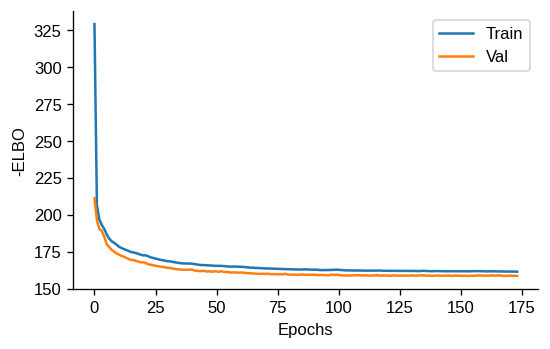

In [5]:
model = lynx.model.HeteroAttnVGAE(model_configs, device=torch.device("cuda"))
model.fit(graph_data, train_configs, DEBUG=True)
res = model.evaluate(
    adata_xenium, adata_desi,
    graph_data=graph_data,
    device=torch.device("cpu"),
)

# Reconstructed gene expression
adata_xenium.layers["px"] = res["px"].copy()

```python
# Save results into either full h5ad (AnnData) or npy (latent embedding)
results_dir = "../../results/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)
adata_xenium.write_h5ad(os.path.join(results_dir, "LYNX_liver_xenium.h5ad"))
np.save(os.path.join(results_dir, "LYNX_liver_desi.npy"), adata_desi.obsm['X_z'])
```

### Reconstruction quality

Observed vs. reconstructed gene expression should fall along the diagonal.

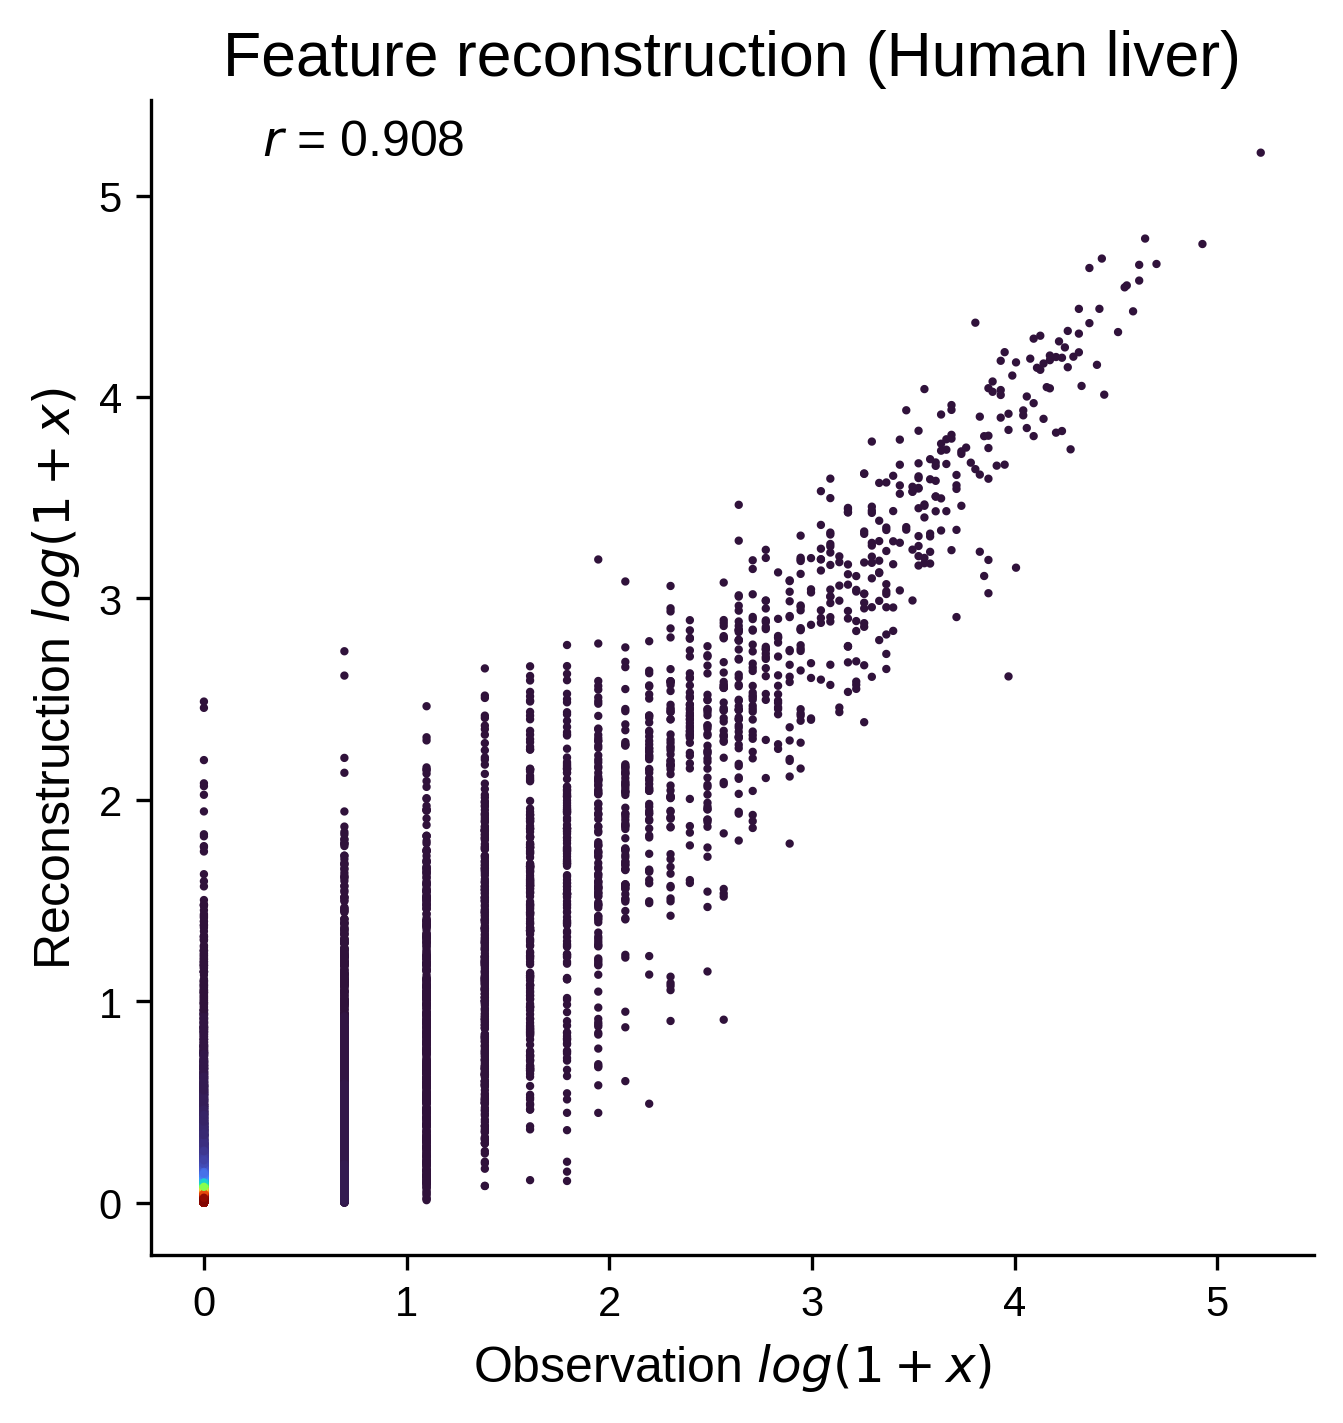

In [6]:
lynx.plot.disp_kde_scatter(
    adata_xenium.X.A.flatten(),
    res.px.flatten(),
    subset_ratio=0.001,
    xlabel=r"Observation $log(1+x)$",
    ylabel=r"Reconstruction $log(1+x)$",
    title="Feature reconstruction (Human liver)",
)

## 4. Load the pre-saved result snapshot

Training above requires the full (large) Xenium/DESI inputs and a GPU. For the
downstream analysis we load a LYNX result snapshot — the same object the
training step produces, carrying the latent embedding `X_z`, the DESI mapping,
and the cell-type labels.

In [7]:
results_dir = "../../results/"
adata_xenium = sc.read_h5ad(os.path.join(results_dir, "LYNX_liver_xenium.h5ad"))
adata_desi = sc.read_h5ad(os.path.join(desi_path, sample_id + ".h5"))
adata_xenium, adata_desi = lynx.io.filter_cells(adata_xenium, adata_desi, by="map")
adata_desi.obsm["X_z"] = np.load(
    os.path.join(results_dir, "LYNX_liver_desi.npy")
).astype(np.float32)

## 5. Gradient Trajectory inference

Fit a principal curve through the latent embedding and assign a continuous
pseudotime `t`. The optional root marker only sets the **orientation** of the gradient (here a periportal gene for transcriptomics and a periportal metabolite for metabolomics). The inferred principal curve reflects the spatially-resolved gradient.

(2, 6)
(20, 6)
Computing pseudotime on principal curve...


2026-06-26 14:18:40.398118: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-26 14:18:40.875041: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


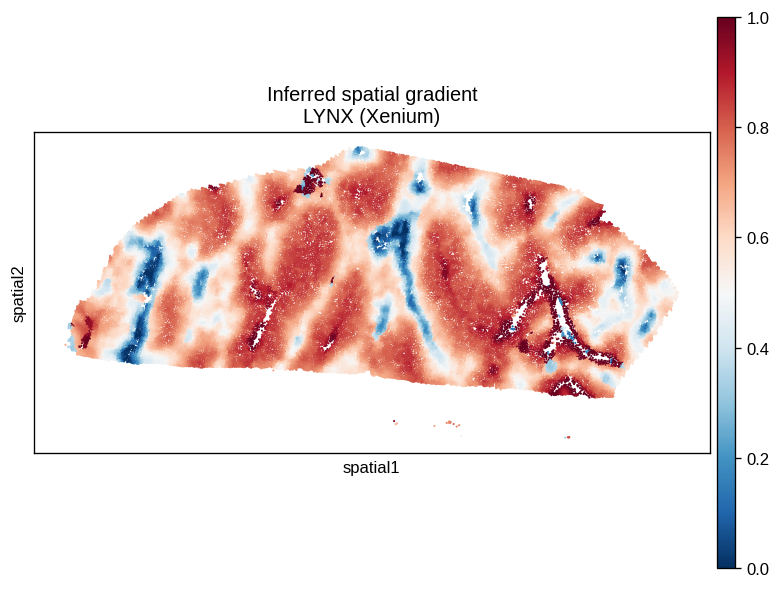

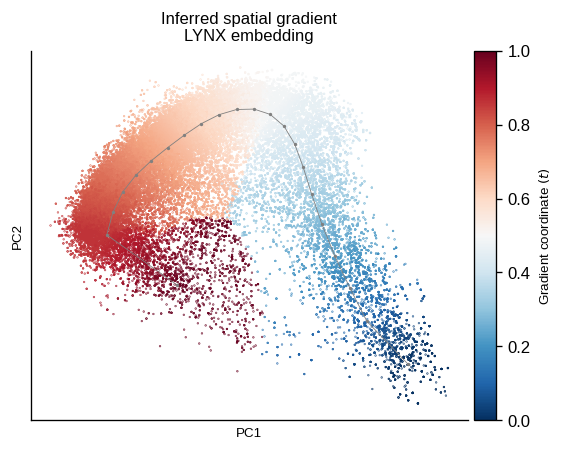

In [8]:
curve = lynx.trajectory.get_curve(adata_xenium, epg_lambda=0.01, trim_radius_ratio=0.5)
lynx.trajectory.compute_pseudotime(adata_xenium, curve, root_marker="DPT")

sq.pl.spatial_scatter(
    adata_xenium, color="t",
    cmap="RdBu_r", size=25, img=False,
    title="Inferred spatial gradient\nLYNX (Xenium)",
)
lynx.plot.disp_trajectory(
    adata_xenium, cmap="RdBu_r",
    title="Inferred spatial gradient\nLYNX embedding",
)

(2, 6)
(20, 6)
Computing pseudotime on principal curve...


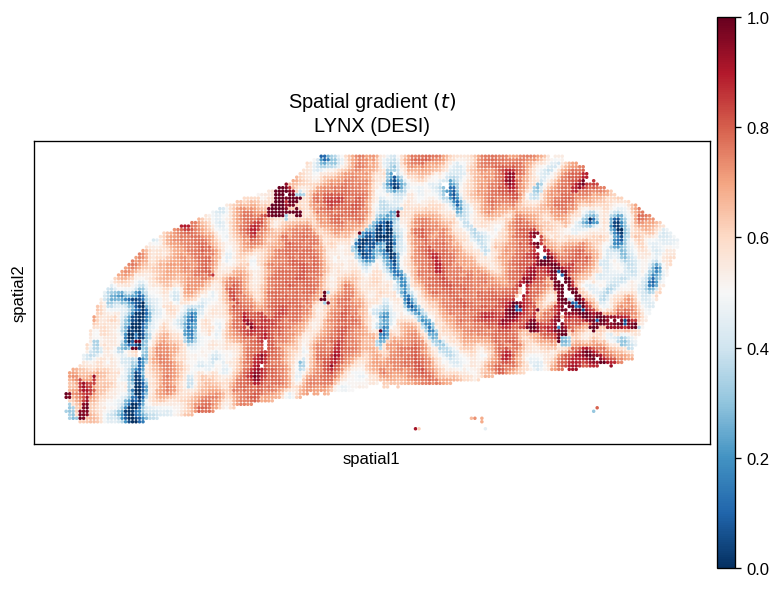

In [9]:
# The same curve fit on the DESI (metabolomics) modality.
curve = lynx.trajectory.get_curve(adata_desi, epg_lambda=0.01, trim_radius_ratio=0.5)
lynx.trajectory.compute_pseudotime(adata_desi, curve, root_marker="Taurine [M-H]-")

sq.pl.spatial_scatter(
    adata_desi, color="t",
    cmap="RdBu_r", size=1, img=False,
    title=r"Spatial gradient $(t)$" + "\nLYNX (DESI)",
)

## 6. Zonation

Discretize the continuous gradient into zones and identify the genes /
metabolites that vary across them.

/home/yinuo/Desktop/azizi_lab/IMS/env/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:488: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)


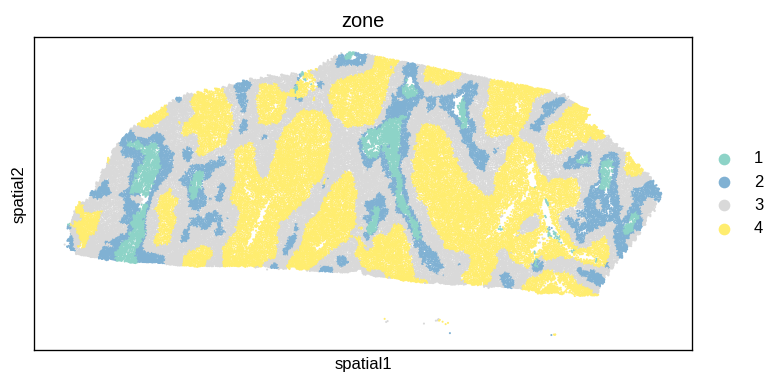

In [10]:
# Normalize raw counts if needed before zone-feature testing.
if adata_xenium.X.toarray()[adata_xenium.X.toarray() > 0].min() == 1.0:
    sc.pp.normalize_total(adata_xenium)
    sc.pp.log1p(adata_xenium)

lynx.utils.get_zonation_features(
    adata_xenium, adata_desi,
    n_zones=4, sample_id=sample_id,
    abundance_test=True, show=False,
)

sq.pl.spatial_scatter(
    adata_xenium, color="zone",
    size=25, img=False, palette="Set3",
)

## 7. Cell–cell interactions

Summarize the inferred interactions across all cell types and test their
significance, then render the overall interaction map.

In [11]:
adata_xenium.uns.keys()

dict_keys(['cell_type_colors', 'edge_index', 'omega', 'spatial', 'graph', 'log1p', 'zones', 'zone_colors'])

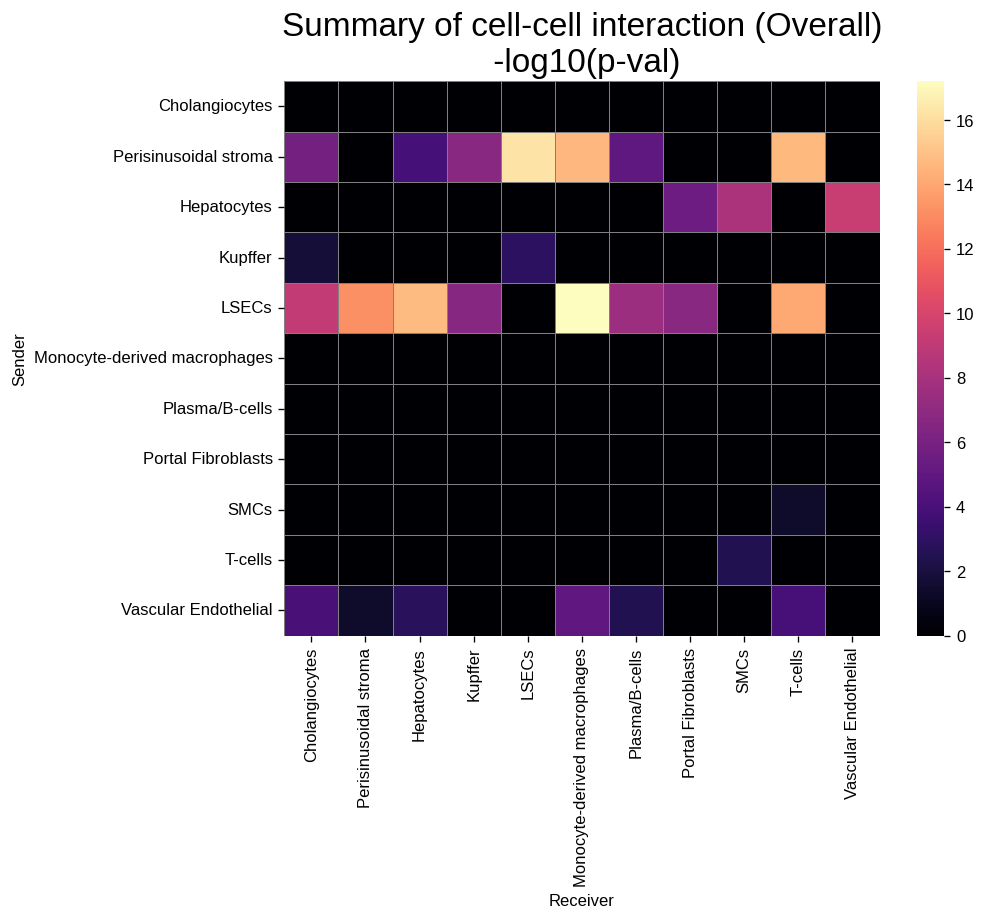

In [ ]:
cci_df = lynx.plot.summarize_cell_interaction(
    adata_xenium,
    cluster_key=cluster_key,
    cluster_labels=cluster_labels,
    show_plot=False,
)

cci_df, pval_df = lynx.test_assoc.test_cci(
    adata_xenium, cci_df,
    cluster_key=cluster_key,
    cluster_labels=cluster_labels,
)

# Prelim visualization of cell-cell interaction signficance (p-values) against spatial co-occurrence.
lynx.plot.disp_heatmap(
    pval_df,
    title="Summary of cell-cell interaction (Overall)\n -log10(p-val)",
)

Next, we summarize cell-cell interaction strength (post-hoc to significance test against cell-type co-occurence) for each zone. Zone 0-3 corresponds to proximity to portal-vein (PV) $\rightarrow$ central-vein (CV) along the inferred porto-central gradient.

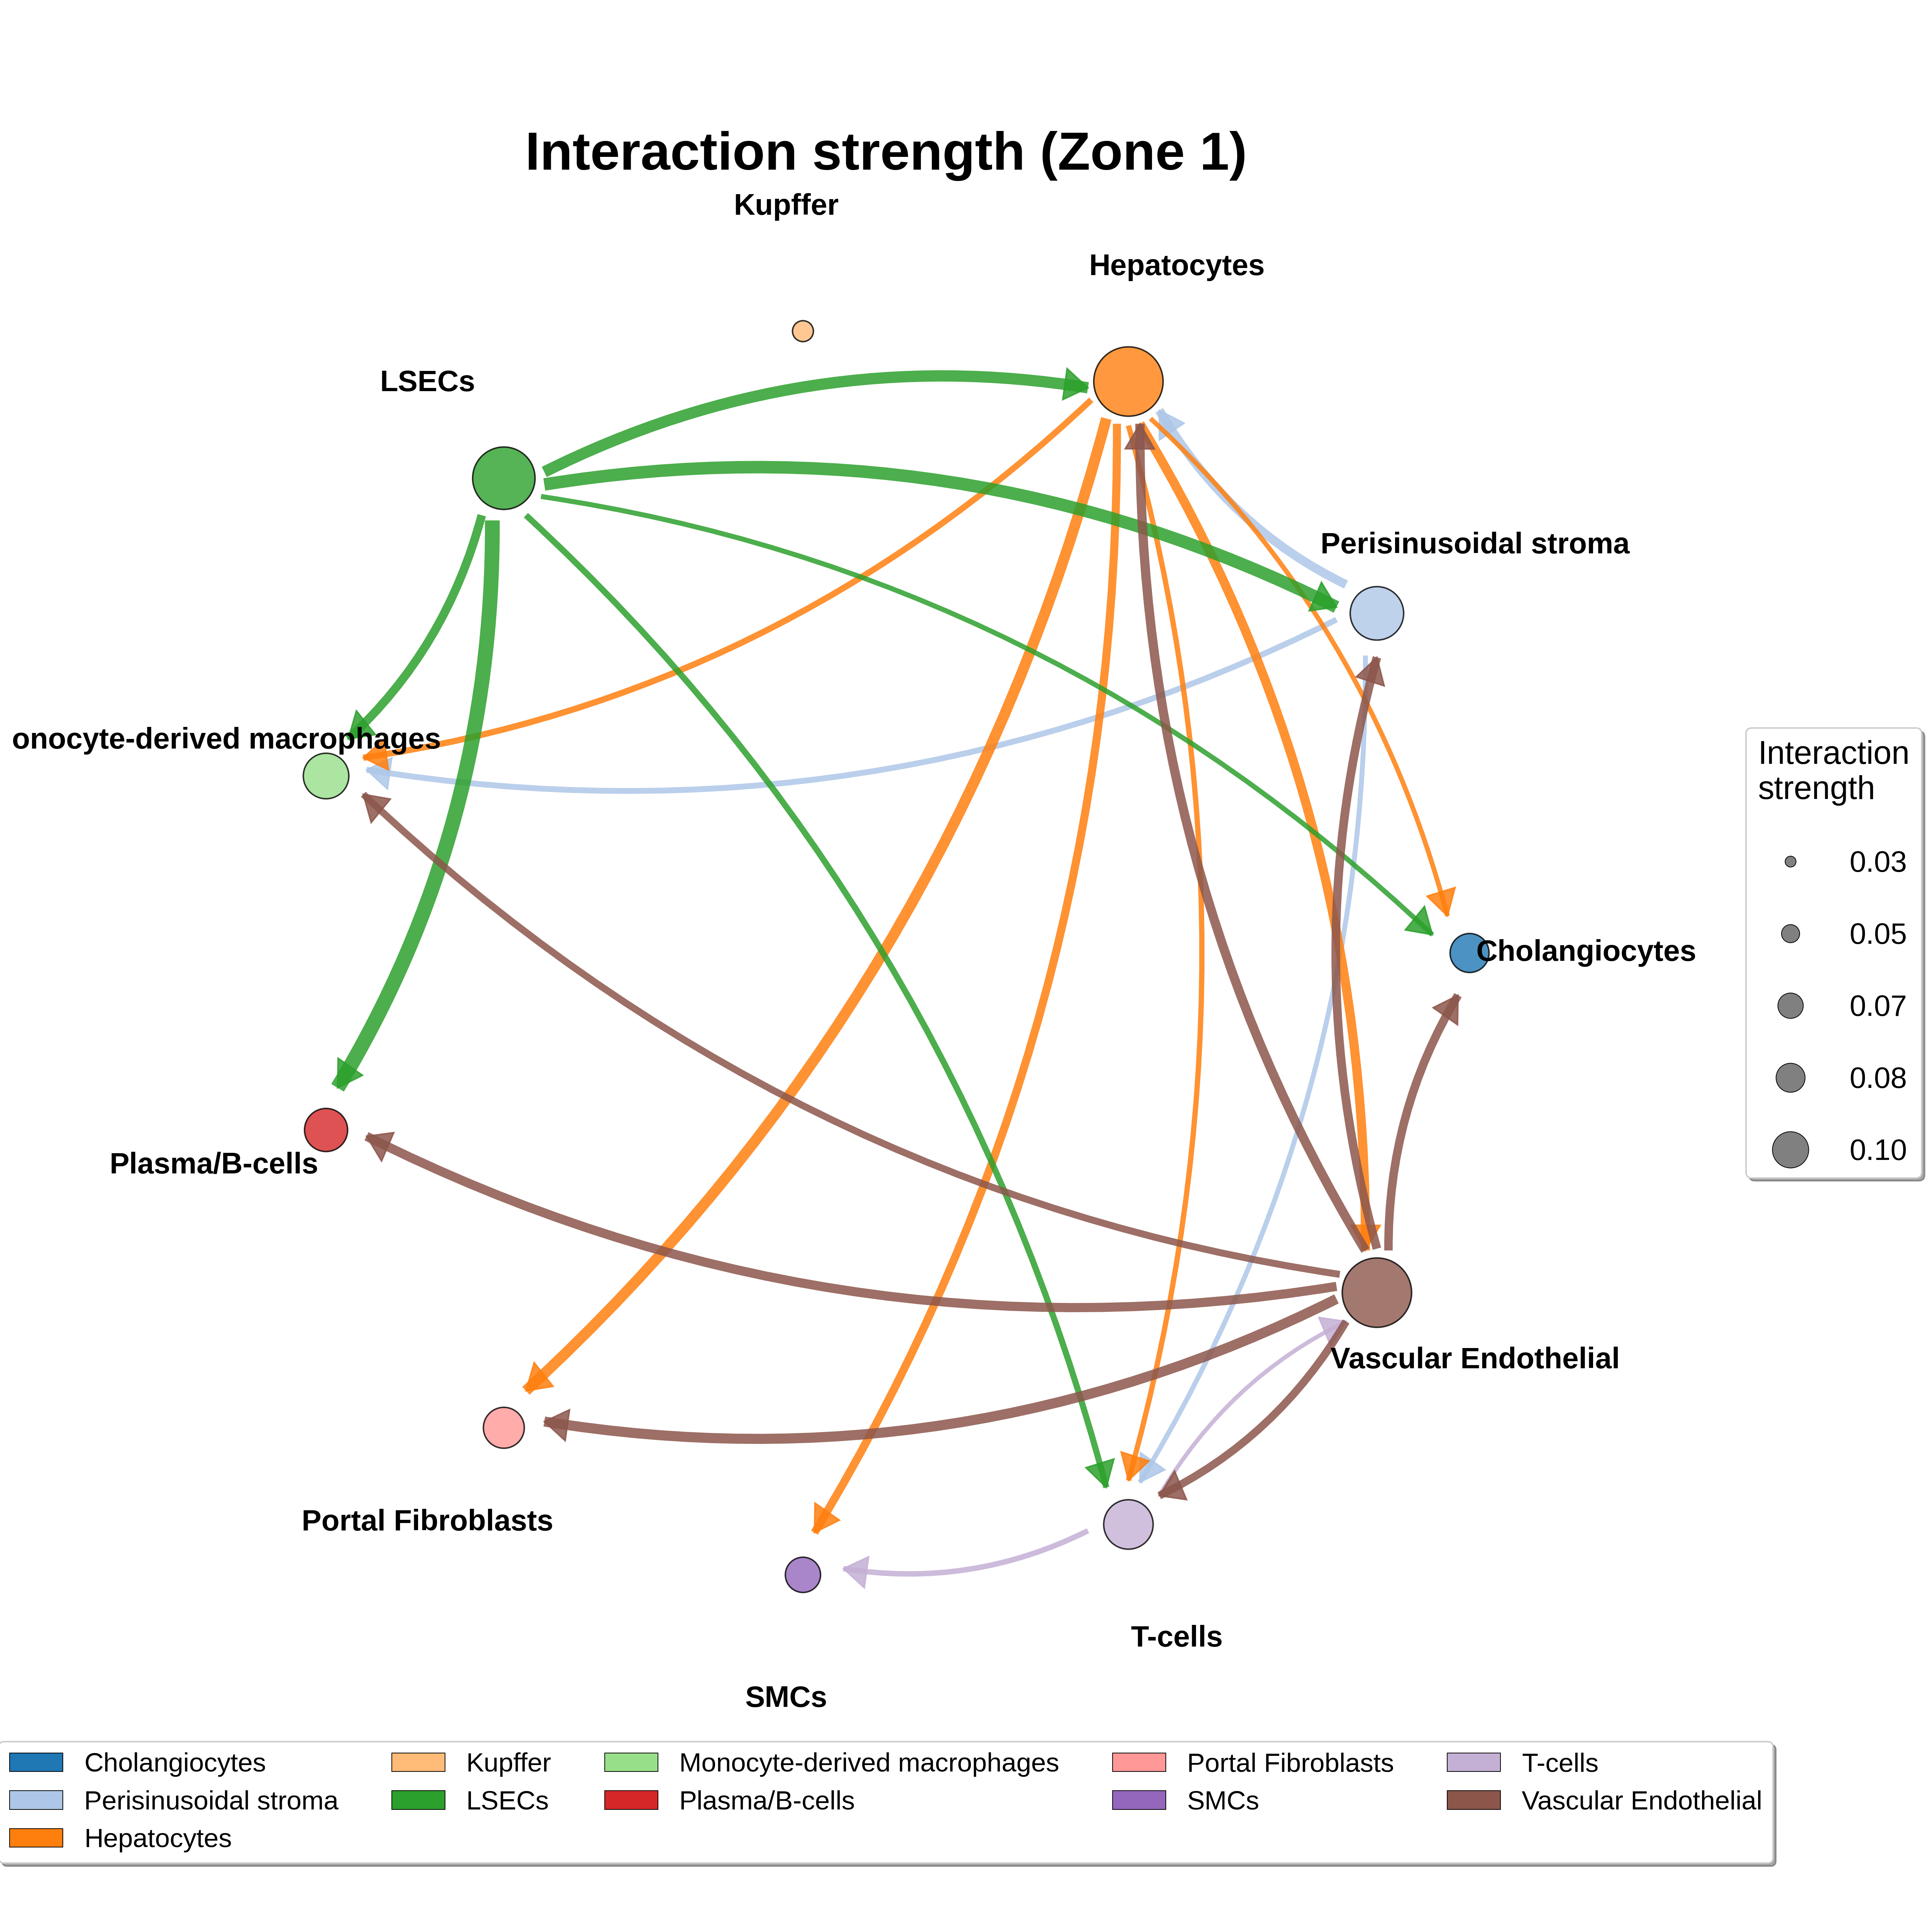

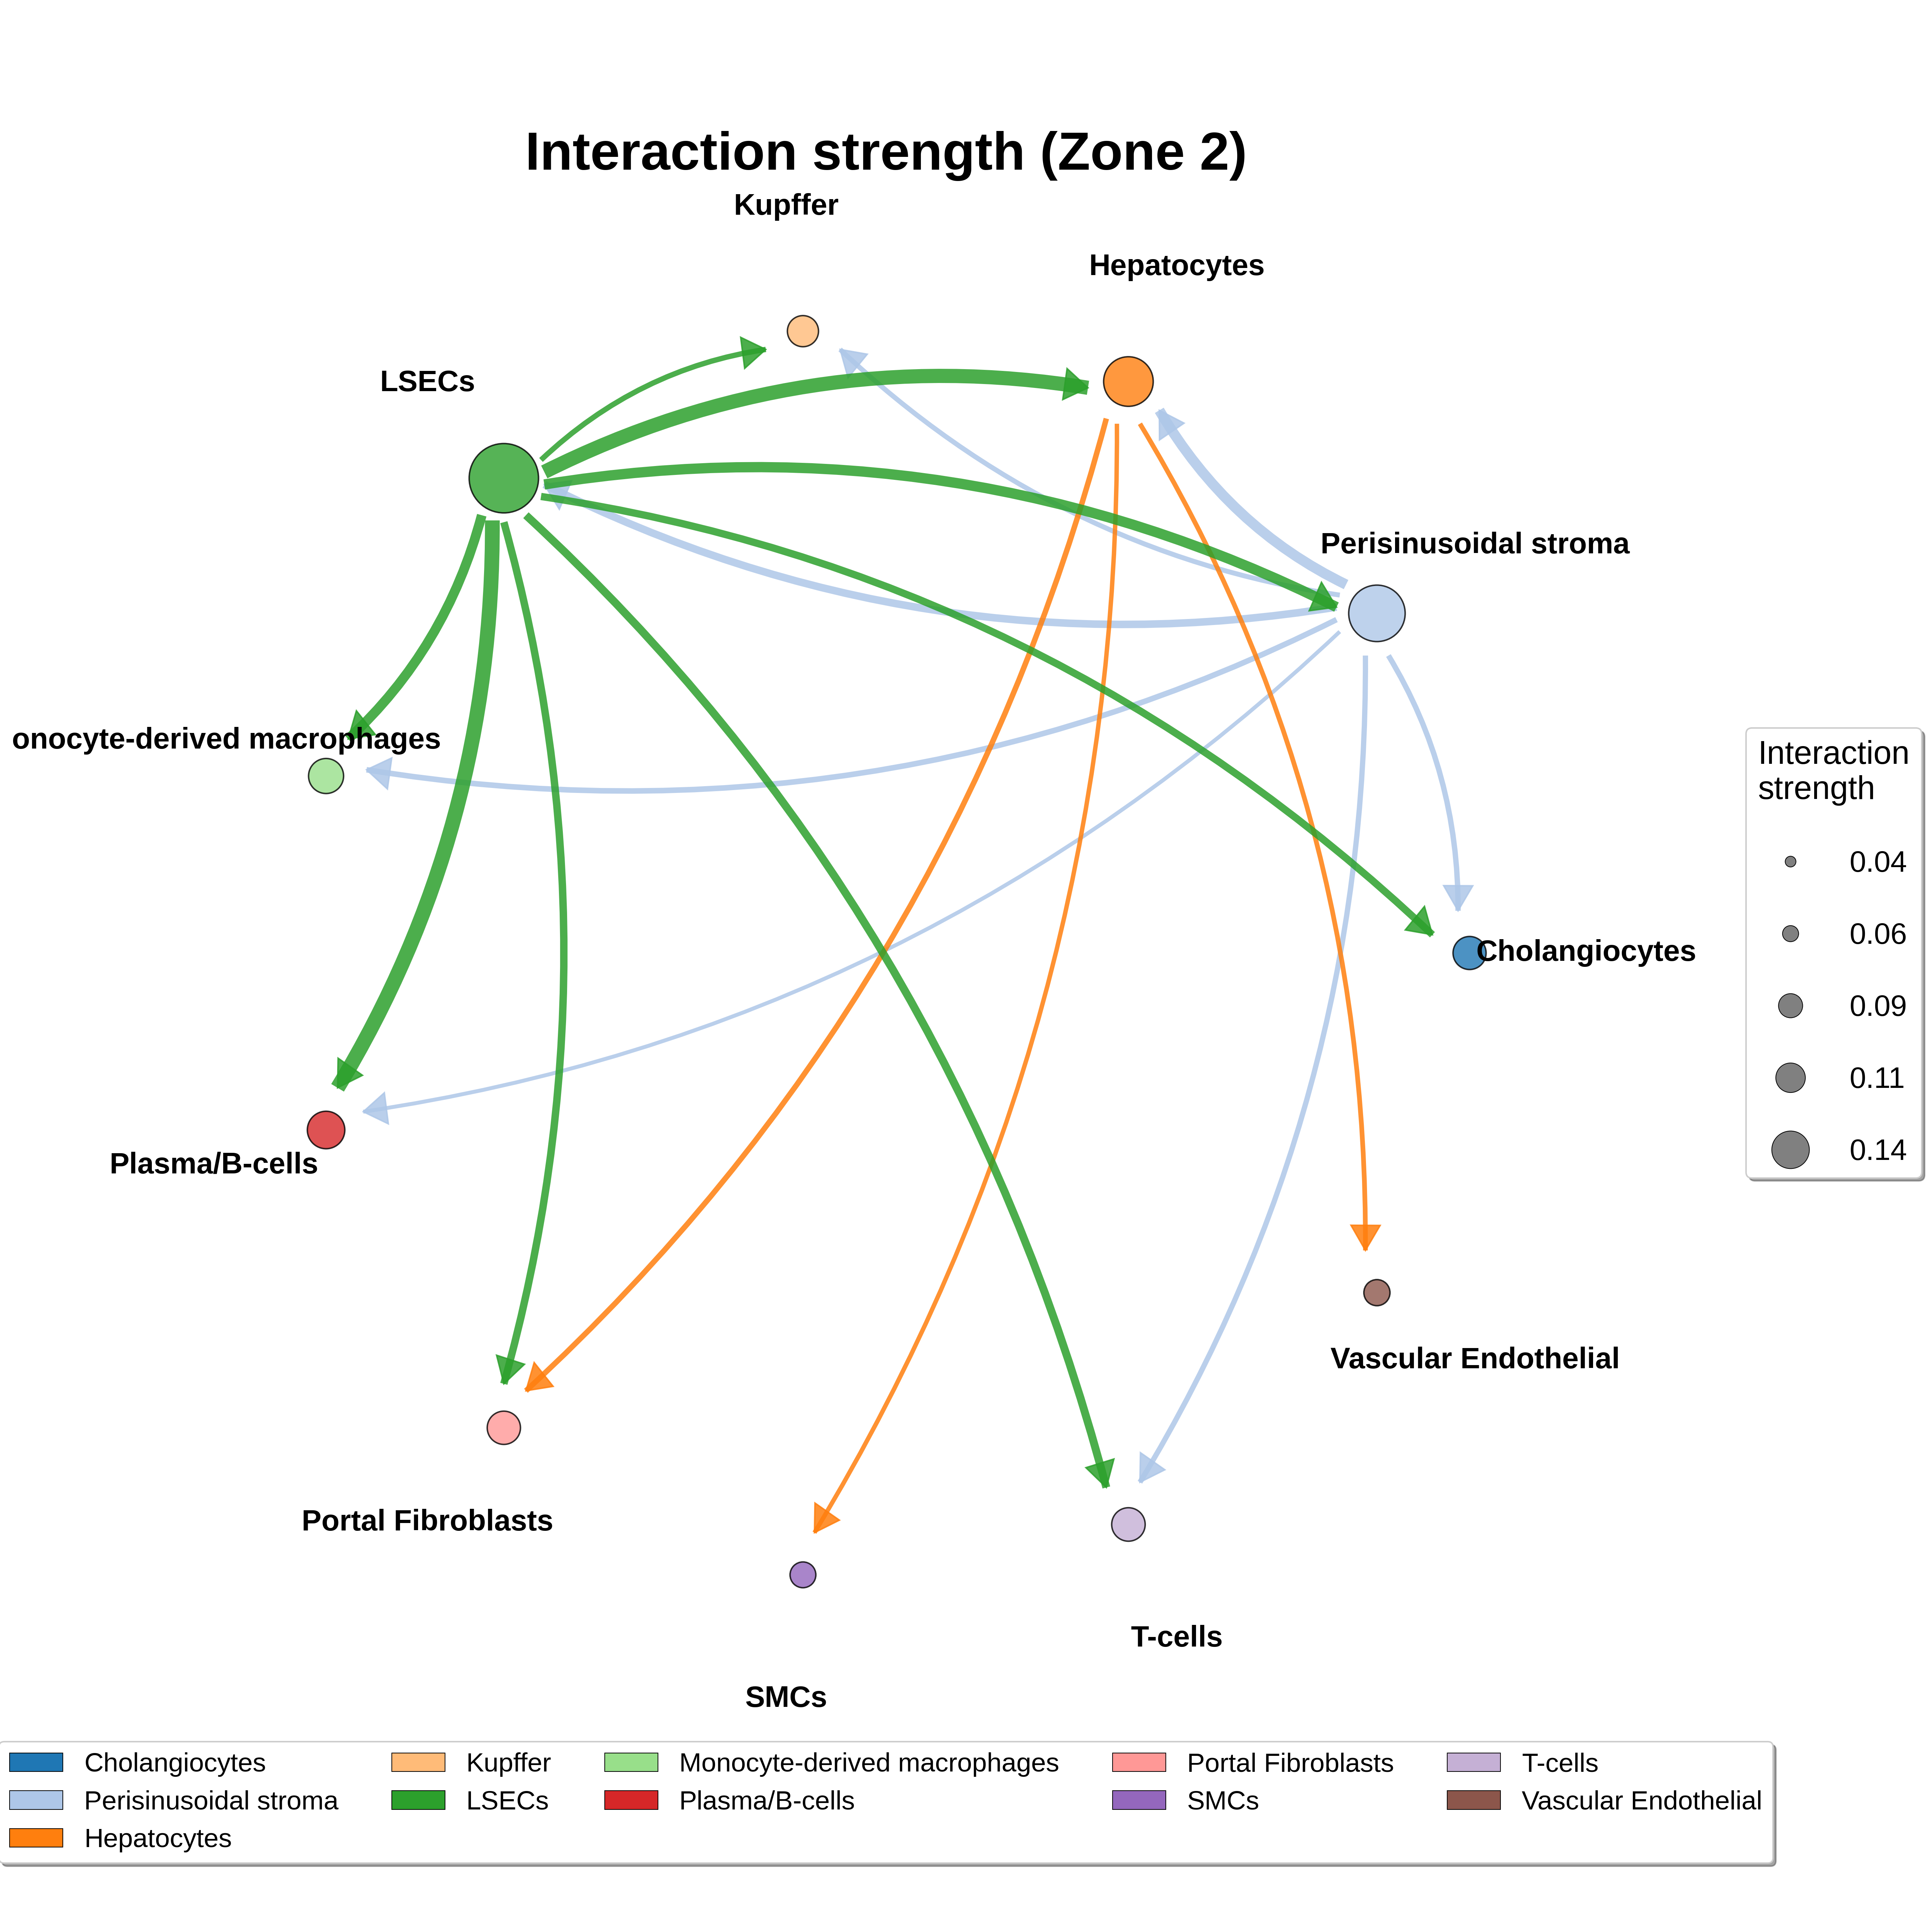

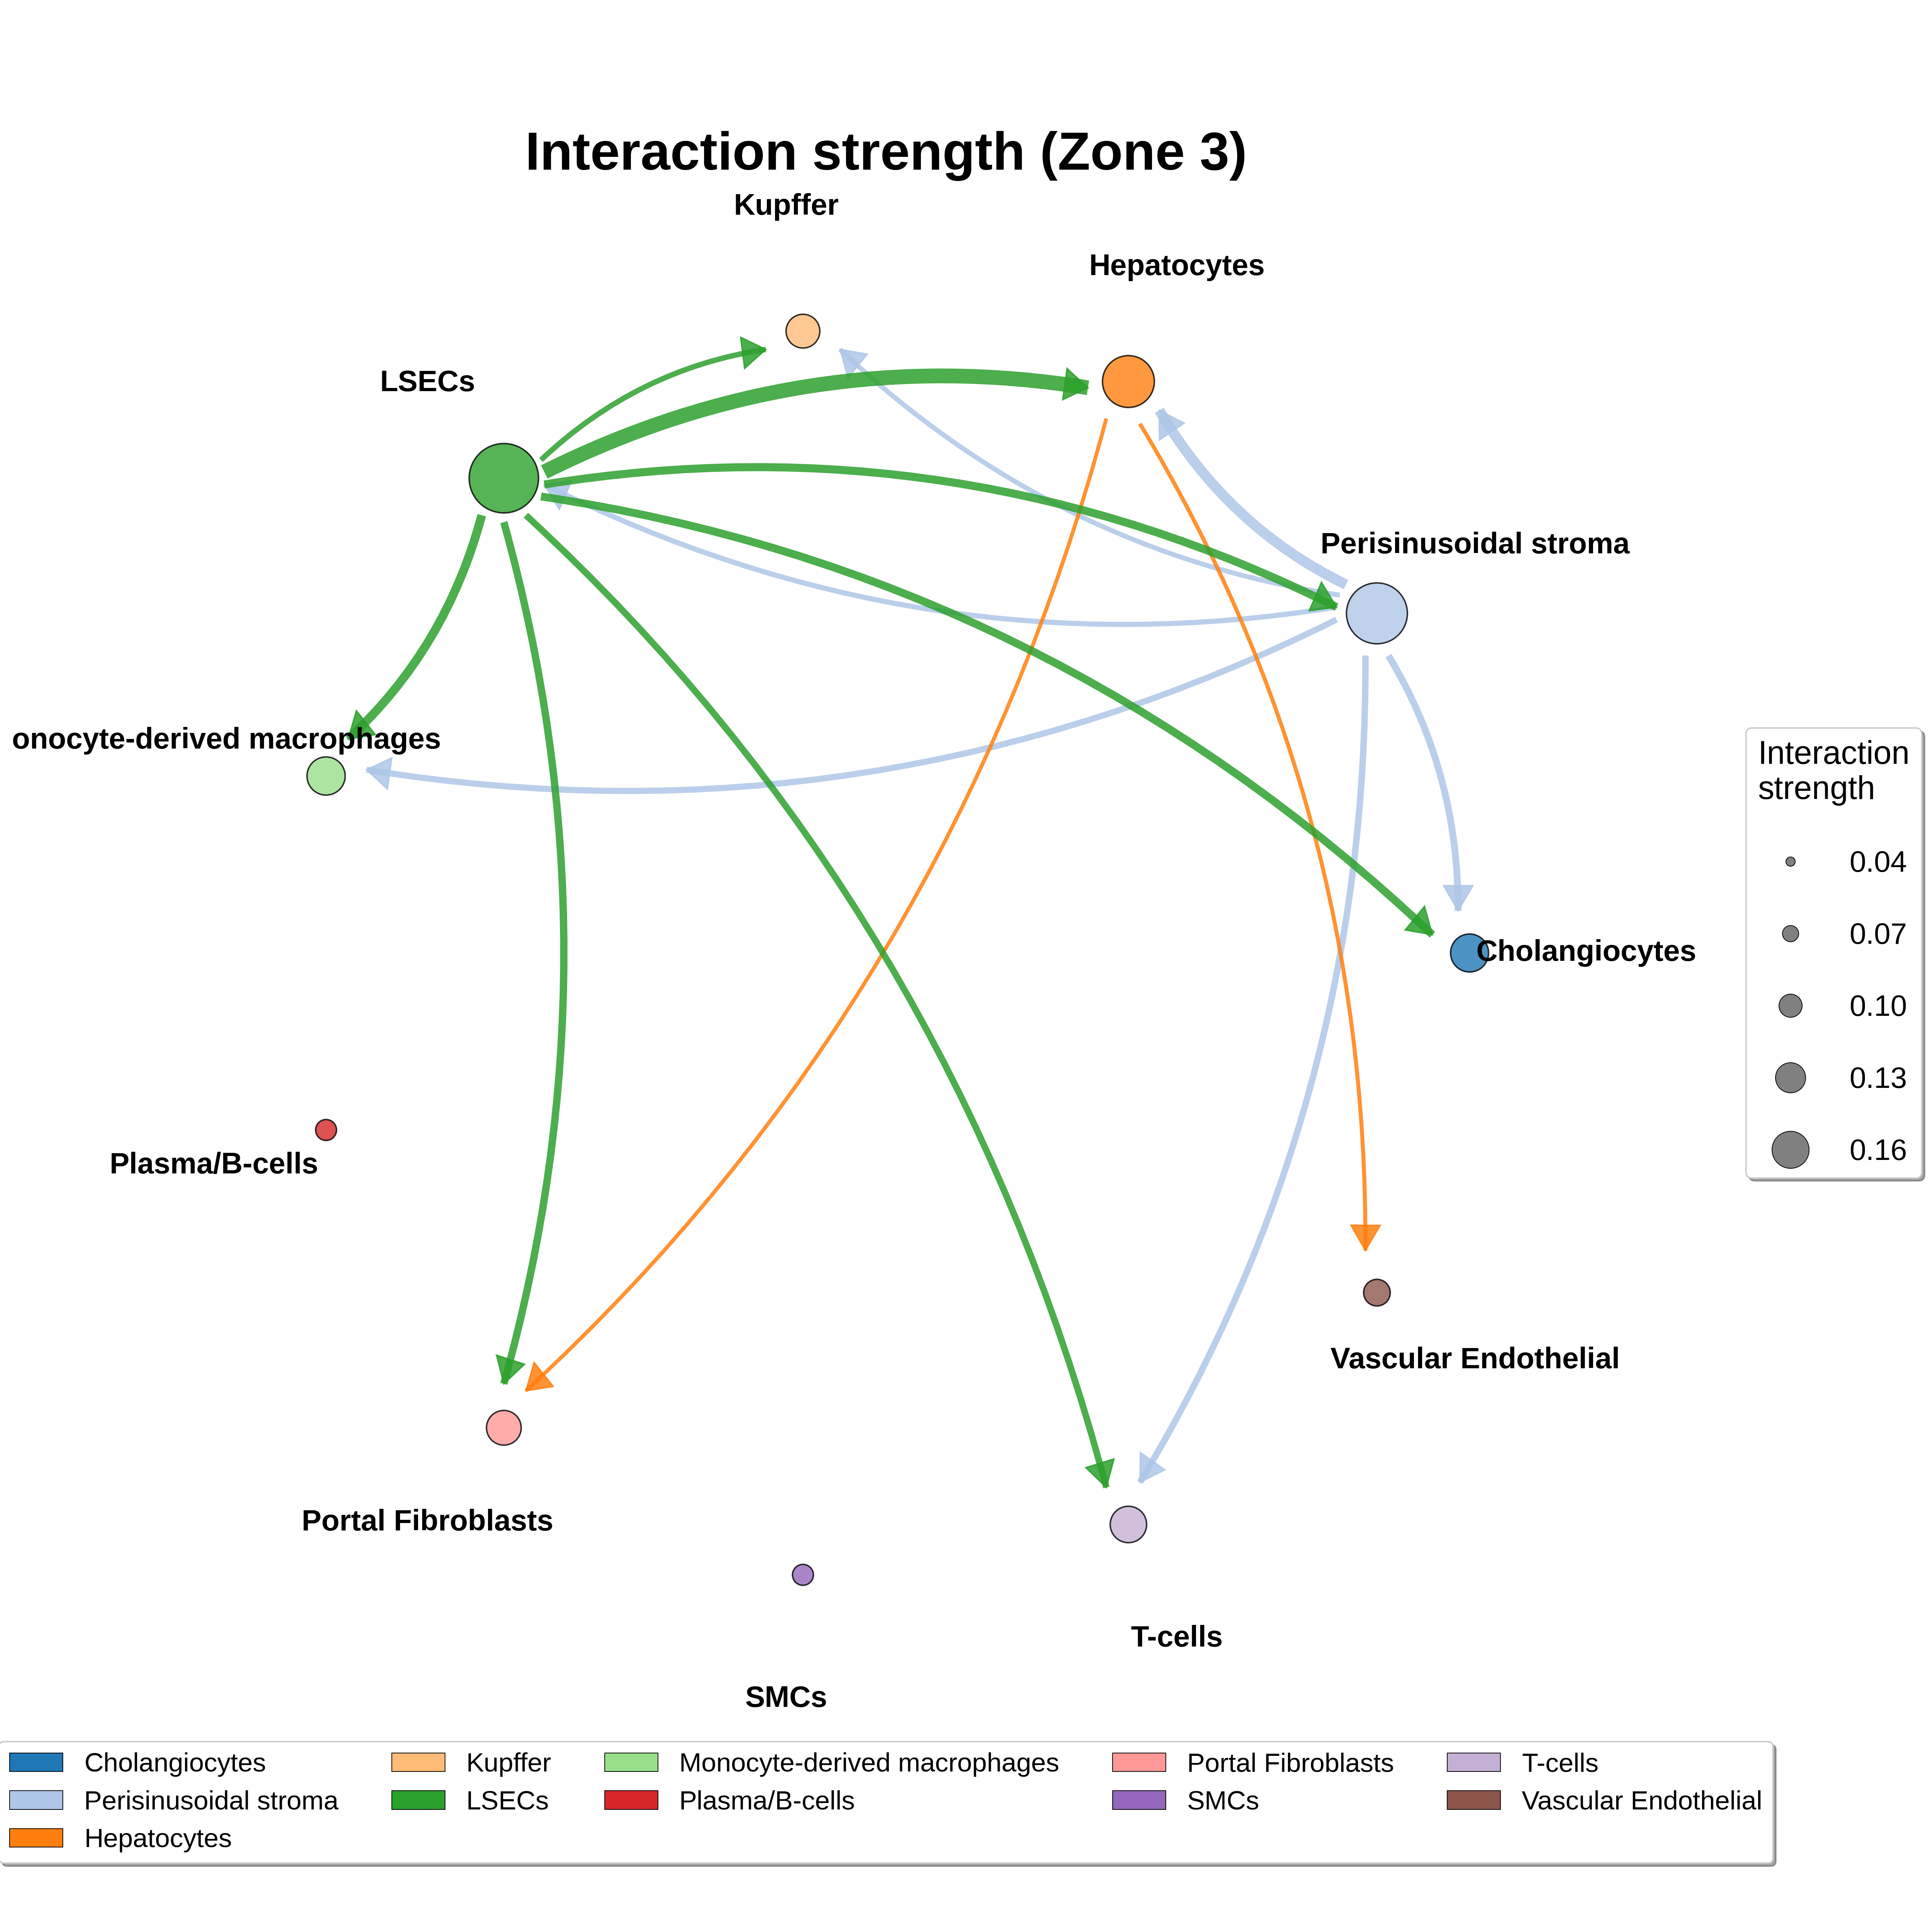

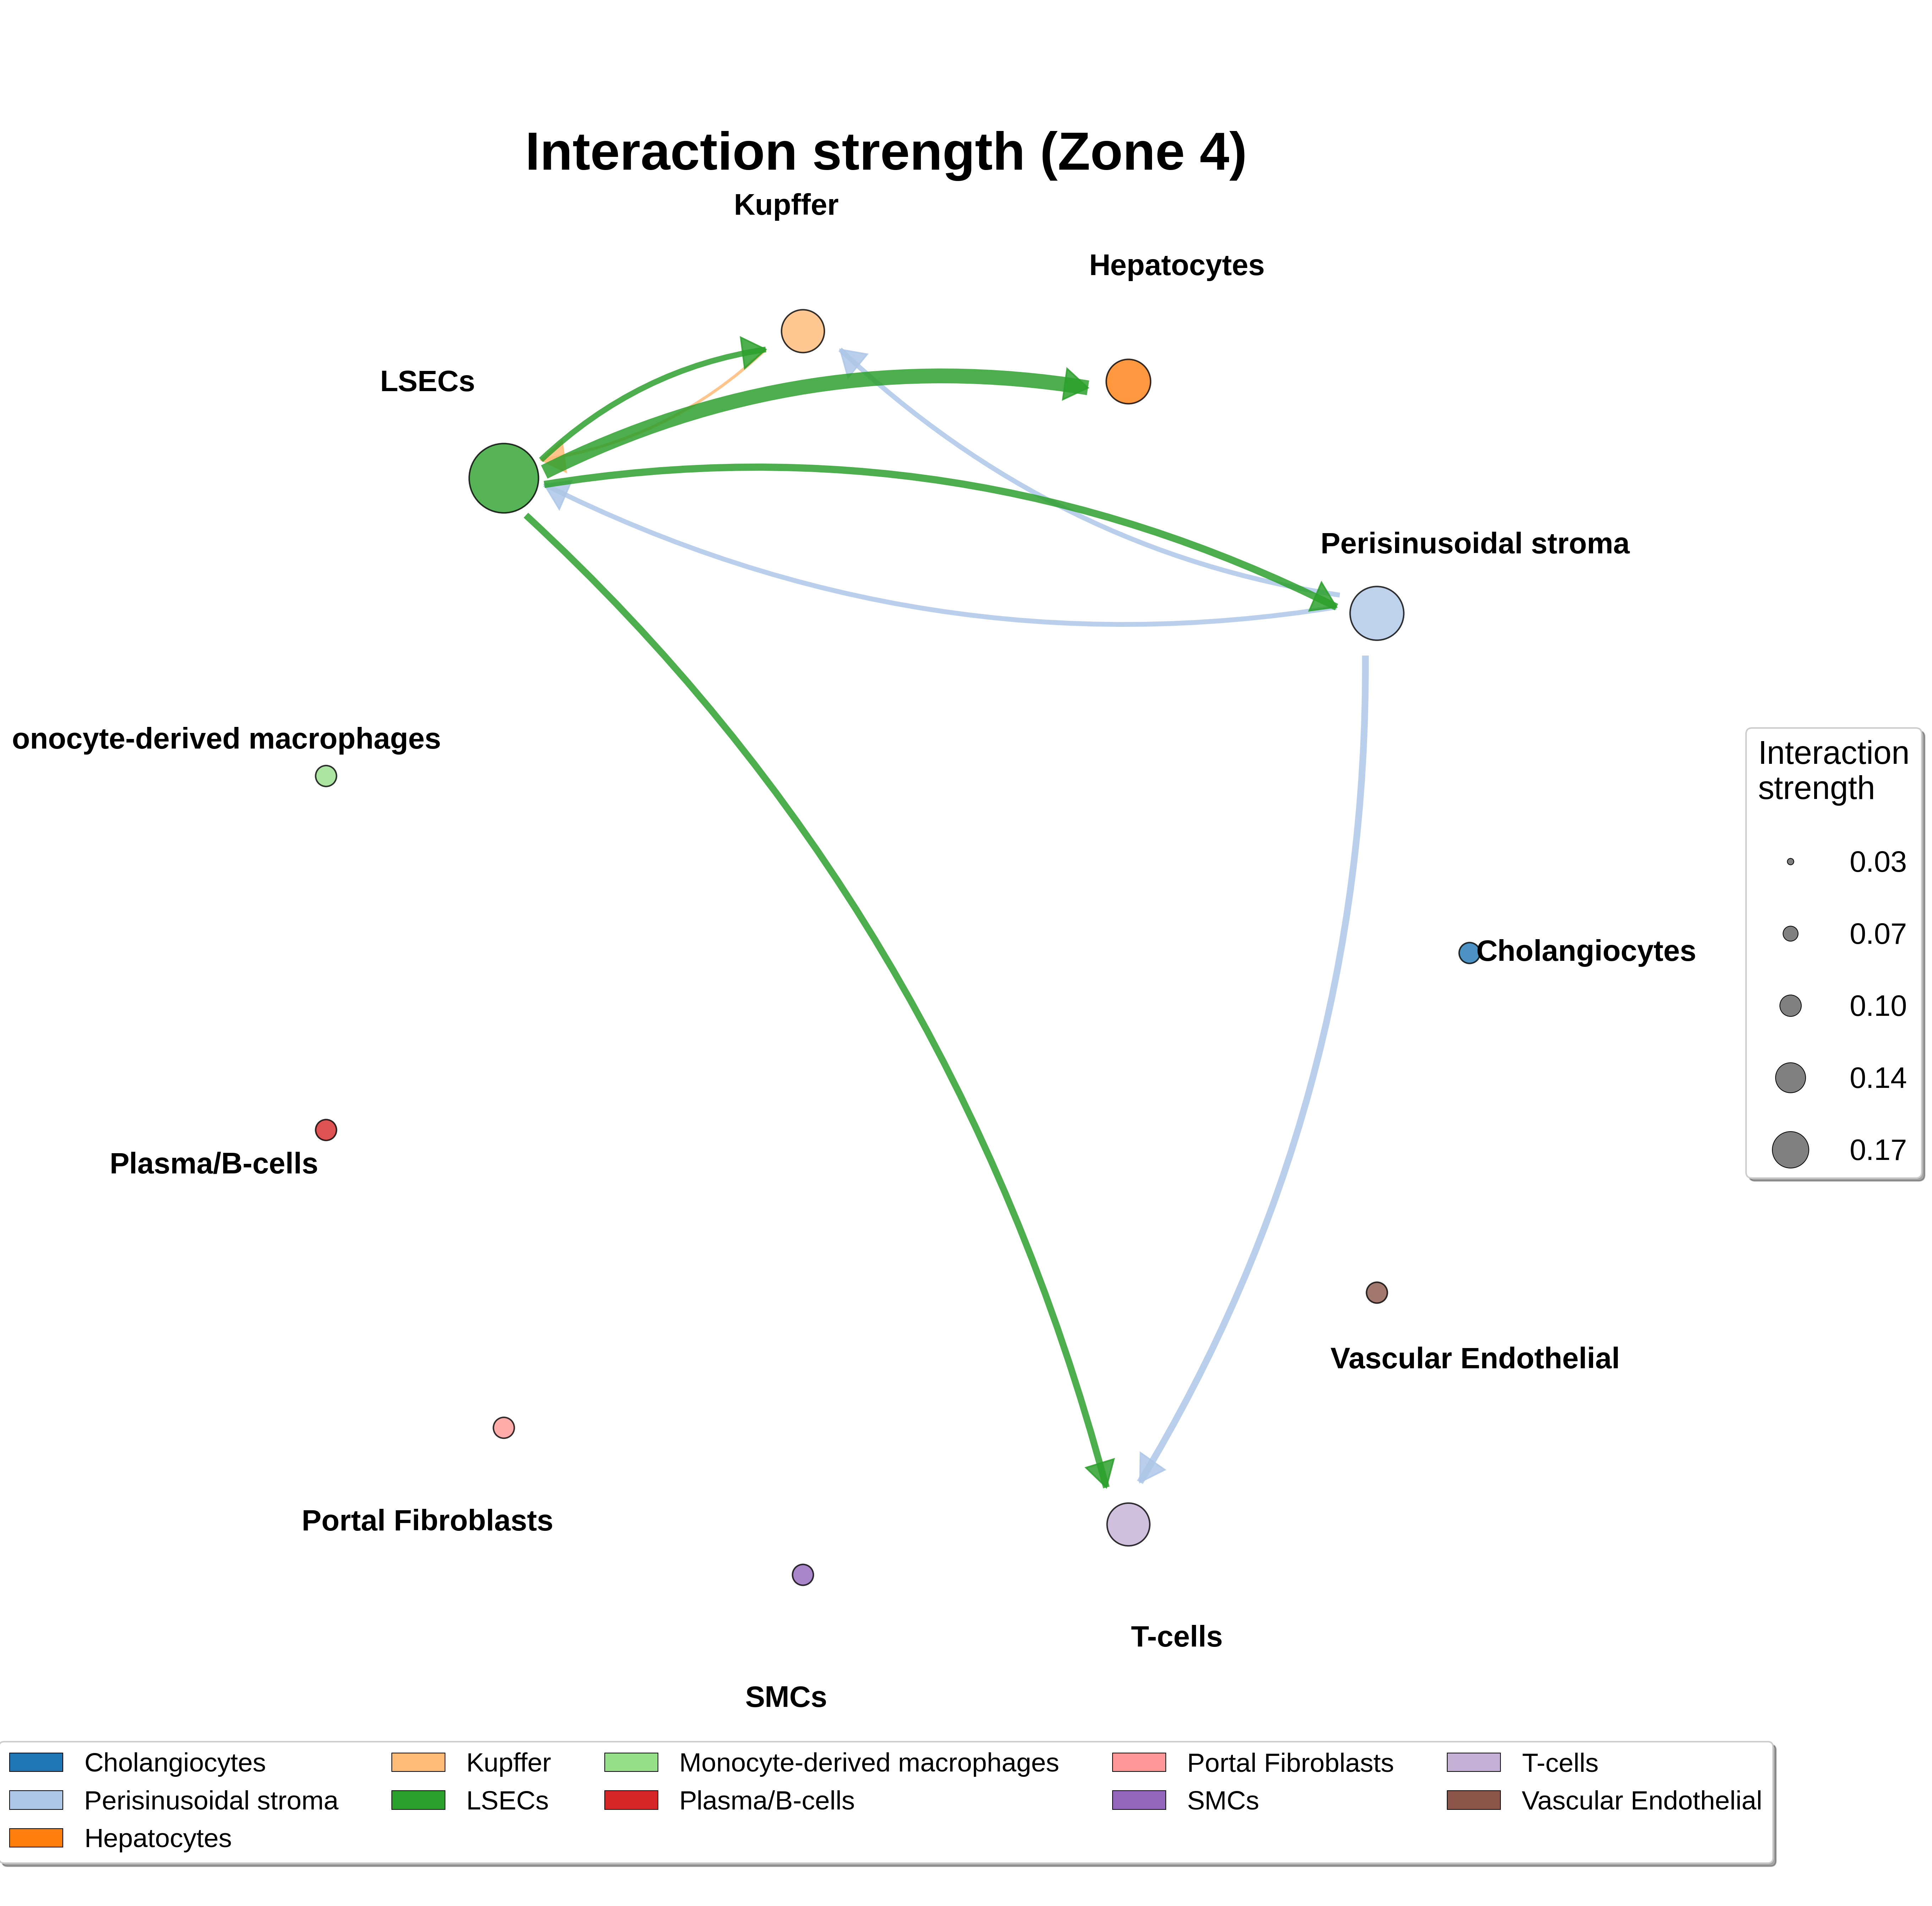

In [ ]:
# Per-zone interaction summary 
for cluster_id in sorted(adata_xenium.obs["zone"].unique()):
    adata_sub = adata_xenium[adata_xenium.obs["zone"] == cluster_id].copy()
    zone_cci_df = lynx.plot.summarize_cell_interaction(
        adata_sub, cluster_key=cluster_key, cluster_labels=cluster_labels,
        show_plot=False,
    )
    zone_cci_df, zone_pval_df = lynx.test_assoc.test_cci(
        adata_sub, zone_cci_df,
        cluster_key=cluster_key, cluster_labels=cluster_labels,
    )

    # `cci_df`: signaling strength (mean of interaction scores) predicted from LYNX
    # `zone_cci_df`: signaling significance (-log10(p-values))
    lynx.plot.netVisual_circle(
        zone_cci_df, vertex_size_max=20, figsize=(18, 18),
        title=f"Interaction strength (Zone {int(cluster_id)})",
    )